# Airbnb Price Prediction System

## Machine Learning Regression Project

This project aims to predict the price of Airbnb listings in New York City
using machine learning techniques.

### Dataset
New York Airbnb Listings 2024

### Tools and Technologies
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Jupyter Notebook
- Streamlit

In [85]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [86]:
df=pd.read_csv("../data/new_york_listings_2024.csv")
df.sample(5)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,...,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license,rating,bedrooms,beds,baths
9862,649493072234819209,Home in Queens · ★4.91 · 1 bedroom · 1 bed · 2...,188362851,Chunhsien,Queens,Flushing,40.758602,-73.812763,Private room,88.0,...,2023-12-31,3.05,3,339,38,OSE-STRREG-0000537,4.91,1,1,2
13789,43723972,Rental unit in New York · Studio · 1 bed · 1 bath,9158874,Rachel,Manhattan,Upper West Side,40.795750,-73.967480,Entire home/apt,150.0,...,2020-07-31,0.02,1,0,0,No License,No rating,Studio,1,1
4260,891457930259313048,Rental unit in Brooklyn · ★5.0 · 1 bedroom · 1...,28648021,Nneka,Brooklyn,Bushwick,40.701225,-73.935640,Entire home/apt,173.0,...,2023-11-02,0.94,1,179,5,No License,5.0,1,1,1
13841,898762908764470763,Rental unit in New York · 2 bedrooms · 2 beds ...,45215560,Em,Manhattan,SoHo,40.724805,-74.000532,Entire home/apt,950.0,...,2023-09-11,0.26,1,365,1,No License,No rating,2,2,2
12078,12866207,Rental unit in Brooklyn · ★4.79 · 1 bedroom · ...,65109990,George,Brooklyn,Clinton Hill,40.685780,-73.964580,Private room,100.0,...,2020-11-15,0.64,4,365,0,No License,4.79,1,1,1.5


In [87]:
df.shape

(20758, 22)

In [88]:
df.size

456676

In [89]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20758 entries, 0 to 20757
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              20758 non-null  int64  
 1   name                            20758 non-null  str    
 2   host_id                         20758 non-null  int64  
 3   host_name                       20758 non-null  str    
 4   neighbourhood_group             20758 non-null  str    
 5   neighbourhood                   20758 non-null  str    
 6   latitude                        20758 non-null  float64
 7   longitude                       20758 non-null  float64
 8   room_type                       20758 non-null  str    
 9   price                           20758 non-null  float64
 10  minimum_nights                  20758 non-null  int64  
 11  number_of_reviews               20758 non-null  int64  
 12  last_review                     20758 non-n

In [90]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,beds
count,2.075800e+04,2.075800e+04,20758.000000,20758.000000,20758.000000,20758.000000,20758.000000,20758.000000,20758.000000,20758.000000,20758.000000,20758.000000
mean,3.034044e+17,1.749316e+08,40.726798,-73.939161,187.776616,28.558435,42.642596,1.257910,18.844108,205.990317,10.852105,1.723721
std,3.901216e+17,1.725541e+08,0.060294,0.061403,1022.797208,33.536518,73.561654,1.904661,70.910834,135.087768,21.357071,1.212272
min,2.595000e+03,1.678000e+03,40.500314,-74.249840,10.000000,1.000000,1.000000,0.010000,1.000000,0.000000,0.000000,1.000000
25%,2.708808e+07,2.041738e+07,40.684150,-73.980710,80.000000,30.000000,4.000000,0.210000,1.000000,87.000000,1.000000,1.000000
50%,4.993003e+07,1.087271e+08,40.722820,-73.949587,125.000000,30.000000,14.000000,0.650000,2.000000,215.000000,3.000000,1.000000
75%,7.216019e+17,3.144102e+08,40.763098,-73.917460,199.000000,30.000000,49.000000,1.800000,5.000000,353.000000,15.000000,2.000000
max,1.054376e+18,5.504035e+08,40.911147,-73.713650,100000.000000,1250.000000,1865.000000,75.490000,713.000000,365.000000,1075.000000,42.000000


In [91]:
df.columns.tolist()

['id',
 'name',
 'host_id',
 'host_name',
 'neighbourhood_group',
 'neighbourhood',
 'latitude',
 'longitude',
 'room_type',
 'price',
 'minimum_nights',
 'number_of_reviews',
 'last_review',
 'reviews_per_month',
 'calculated_host_listings_count',
 'availability_365',
 'number_of_reviews_ltm',
 'license',
 'rating',
 'bedrooms',
 'beds',
 'baths']

In [92]:
df.isnull().sum()

id                                0
name                              0
host_id                           0
host_name                         0
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
last_review                       0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
number_of_reviews_ltm             0
license                           0
rating                            0
bedrooms                          0
beds                              0
baths                             0
dtype: int64

In [93]:
df.duplicated().sum()

np.int64(0)

In [94]:
print("Room Types:")
print(df['room_type'].unique())

print("\nNeighbourhood Groups:")
print(df['neighbourhood_group'].unique())

print("\nBedrooms:")
print(df['bedrooms'].unique())

print("\nBathrooms:")
print(df['baths'].unique())

Room Types:
<ArrowStringArray>
['Private room', 'Entire home/apt', 'Hotel room', 'Shared room']
Length: 4, dtype: str

Neighbourhood Groups:
<ArrowStringArray>
['Brooklyn', 'Manhattan', 'Queens', 'Bronx', 'Staten Island']
Length: 5, dtype: str

Bedrooms:
<ArrowStringArray>
['1', '2', 'Studio', '3', '6', '5', '4', '7', '15', '9', '8', '14']
Length: 12, dtype: str

Bathrooms:
<ArrowStringArray>
['Not specified',             '1',             '2',           '1.5',
             '3',             '4',           '3.5',             '0',
           '2.5',             '5',           '4.5',             '6',
           '5.5',          '11.5',           '6.5',             '7',
          '15.5']
Length: 17, dtype: str


In [95]:
print("Bedrooms:")
print(df['bedrooms'].unique())

print("\nRating:")
print(df['rating'].unique())

print("\nRoom Types:")
print(df['room_type'].unique())

Bedrooms:
<ArrowStringArray>
['1', '2', 'Studio', '3', '6', '5', '4', '7', '15', '9', '8', '14']
Length: 12, dtype: str

Rating:
<ArrowStringArray>
[     '5.0 ',     '4.67 ',     '4.17 ',     '4.64 ',     '4.91 ',     '4.33 ',
     '4.50 ',     '4.79 ', 'No rating',     '4.71 ',
 ...
     '2.89 ',     '3.55 ',     '3.85 ',     '1.75 ',     '3.58 ',     '3.22 ',
     '3.77 ',     '3.65 ',     '3.87 ',     '2.75 ']
Length: 162, dtype: str

Room Types:
<ArrowStringArray>
['Private room', 'Entire home/apt', 'Hotel room', 'Shared room']
Length: 4, dtype: str


## Data Cleaning

In this section, we clean inconsistent and non-numeric values
before performing exploratory data analysis and model training.

In [96]:
df['bedrooms'] = df['bedrooms'].replace('Studio', 0)
df['bedrooms'] = pd.to_numeric(df['bedrooms'], errors='coerce')

In [97]:
df['bedrooms'].unique()

array([ 1,  2,  0,  3,  6,  5,  4,  7, 15,  9,  8, 14])

In [98]:
df['baths'] = pd.to_numeric(df['baths'], errors='coerce')
df['baths'].unique()

array([ nan,  1. ,  2. ,  1.5,  3. ,  4. ,  3.5,  0. ,  2.5,  5. ,  4.5,
        6. ,  5.5, 11.5,  6.5,  7. , 15.5])

In [99]:
df['rating'] = df['rating'].replace('No rating', np.nan)
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

In [100]:
df['rating'].head()


0    5.00
1    4.67
2    4.17
3    4.64
4    4.91
Name: rating, dtype: float64

In [101]:
df[['bedrooms', 'beds', 'baths', 'rating']].info()

<class 'pandas.DataFrame'>
RangeIndex: 20758 entries, 0 to 20757
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   bedrooms  20758 non-null  int64  
 1   beds      20758 non-null  int64  
 2   baths     20745 non-null  float64
 3   rating    17006 non-null  float64
dtypes: float64(2), int64(2)
memory usage: 648.8 KB


In [102]:
df[['bedrooms', 'beds', 'baths', 'rating']].isnull().sum()

bedrooms       0
beds           0
baths         13
rating      3752
dtype: int64

## Handling Missing Values

Before performing further data analysis and building the machine learning model,
we need to identify and handle missing values in the dataset.

Missing values can affect statistical analysis and may cause errors when
training machine learning models. However, different columns may require
different approaches for handling missing values.

Therefore, we will first identify the columns containing missing values and
calculate both the number and percentage of missing values. Based on the type
and meaning of each column, we will then decide whether to replace, remove,
or otherwise handle the missing values.

In [103]:
missing = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df)) * 100
})

missing = missing[missing['Missing Values'] > 0]

missing.sort_values('Missing Values', ascending=False)

,Missing Values,Missing %
rating,3752,18.074959
baths,13,0.062626


## Handling Missing Values

The missing-value analysis shows that only the `rating` and `baths` columns
contain missing values.

The `baths` column has only a small number of missing values, so these values
can be replaced using the median of the column.

The `rating` column has a larger proportion of missing values. Since ratings
are numerical and can vary depending on the listing, the median is used to
replace the missing values. The median is less affected by extreme values
than the mean.

Using the median allows us to retain these listings instead of removing them
from the dataset.

In [104]:
df['baths'] = df['baths'].fillna(df['baths'].median())

df['rating'] = df['rating'].fillna(df['rating'].median())

In [105]:
df.isnull().sum()

id                                0
name                              0
host_id                           0
host_name                         0
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
last_review                       0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
number_of_reviews_ltm             0
license                           0
rating                            0
bedrooms                          0
beds                              0
baths                             0
dtype: int64

In [106]:
df['price'].describe()

count     20758.000000
mean        187.776616
std        1022.797208
min          10.000000
25%          80.000000
50%         125.000000
75%         199.000000
max      100000.000000
Name: price, dtype: float64

## Detecting Price Outliers Using IQR

The Interquartile Range (IQR) method is used to identify potential outliers
in the `price` column.

The IQR is calculated as:

**IQR = Q3 - Q1**

where:
- Q1 is the 25th percentile
- Q3 is the 75th percentile

A value is considered a potential outlier if it is:

**Below Q1 - 1.5 × IQR**

or

**Above Q3 + 1.5 × IQR**

This method is suitable for the `price` column because the distribution is
strongly right-skewed.

In [107]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 80.0
Q3: 199.0
IQR: 119.0
Lower Bound: -98.5
Upper Bound: 377.5


In [108]:
outliers = df[
    (df['price'] < lower_bound) |
    (df['price'] > upper_bound)
]

print("Number of outliers:", len(outliers))
print("Percentage of outliers:", len(outliers) / len(df) * 100)

print("Lower outliers:", (df['price'] < lower_bound).sum())
print("Upper outliers:", (df['price'] > upper_bound).sum())

Number of outliers: 1385
Percentage of outliers: 6.672126409095289
Lower outliers: 0
Upper outliers: 1385


In [109]:
outliers['price'].describe()

count      1385.000000
mean        911.547292
std        3878.935176
min         378.000000
25%         430.000000
50%         526.000000
75%         782.000000
max      100000.000000
Name: price, dtype: float64

In [110]:
outliers['price'].sort_values(ascending=False).head(20)

3990     100000.0
5492     100000.0
4528      10000.0
6874      10000.0
901       10000.0
2952      10000.0
3140      10000.0
3026      10000.0
10894      9994.0
11261      7590.0
7857       7500.0
4967       7498.0
15054      7314.0
11042      7184.0
11235      5609.0
1986       5000.0
13579      4929.0
9584       4000.0
15365      3999.0
8668       3600.0
Name: price, dtype: float64

In [111]:
outliers[
    ['name', 'room_type', 'neighbourhood_group',
     'neighbourhood', 'price', 'bedrooms', 'beds', 'baths','reviews_per_month']
].sort_values('price', ascending=False).head(20)

,name,room_type,neighbourhood_group,neighbourhood,price,bedrooms,beds,baths,reviews_per_month
3990,Rental unit in Brooklyn · ★4.48 · 1 bedroom · ...,Private room,Brooklyn,Bedford-Stuyvesant,100000.0,1,1,1.0,0.96
5492,Rental unit in Brooklyn · ★4.33 · 1 bedroom · ...,Private room,Brooklyn,Bedford-Stuyvesant,100000.0,1,1,1.0,0.45
4528,Boutique hotel in New York · ★3.33 · 1 bedroom...,Private room,Manhattan,Midtown,10000.0,1,1,1.0,0.06
6874,Rental unit in New York · Studio · 1 bed · 1 bath,Entire home/apt,Manhattan,Financial District,10000.0,0,1,1.0,0.04
901,Boutique hotel in New York · 1 bedroom · 1 bed...,Private room,Manhattan,Midtown,10000.0,1,1,1.0,0.02
2952,Rental unit in Queens · ★4.14 · 2 bedrooms · 2...,Entire home/apt,Queens,Long Island City,10000.0,2,2,1.0,0.31
3140,Boutique hotel in New York · ★3.40 · 1 bedroom...,Private room,Manhattan,Midtown,10000.0,1,2,1.0,0.10
3026,Loft in New York · ★4.50 · 4 bedrooms · 5 beds...,Shared room,Manhattan,Murray Hill,10000.0,4,5,2.0,0.17
10894,Home in Bronx · ★4.30 · 1 bedroom · 1 bed · 1 ...,Private room,Bronx,Longwood,9994.0,1,1,1.0,0.32
11261,Hotel in NEW YORK · ★5.0 · 1 bedroom · 1 bed ·...,Hotel room,Manhattan,Theater District,7590.0,1,1,1.0,0.07


In [112]:
df['price'].quantile([0.90, 0.95, 0.99, 0.995, 0.999])

0.900     309.000
0.950     430.000
0.990     999.000
0.995    1370.235
0.999    3513.851
Name: price, dtype: float64

## Evaluating Extreme Price Values

The IQR method identified 1,385 potential upper outliers, representing
approximately 6.67% of the dataset.

However, the IQR threshold of $377.50 is relatively low compared with the
overall price distribution. For example, the 99th percentile is approximately
$999.

Therefore, not all IQR outliers should be considered invalid data. Many may
represent legitimate high-priced Airbnb listings.

Instead of removing all IQR outliers, we will investigate the extreme end of
the price distribution separately and identify values that are likely to be
data anomalies.

In [113]:
extreme_prices = df[df['price'] >= 5000]

print("Listings with price >= $5,000:", len(extreme_prices))

extreme_prices[
    ['name', 'room_type', 'neighbourhood_group',
     'neighbourhood', 'price', 'bedrooms', 'beds', 'baths']
].sort_values('price', ascending=False)

Listings with price >= $5,000: 16


,name,room_type,neighbourhood_group,neighbourhood,price,bedrooms,beds,baths
3990,Rental unit in Brooklyn · ★4.48 · 1 bedroom · ...,Private room,Brooklyn,Bedford-Stuyvesant,100000.0,1,1,1.0
5492,Rental unit in Brooklyn · ★4.33 · 1 bedroom · ...,Private room,Brooklyn,Bedford-Stuyvesant,100000.0,1,1,1.0
901,Boutique hotel in New York · 1 bedroom · 1 bed...,Private room,Manhattan,Midtown,10000.0,1,1,1.0
2952,Rental unit in Queens · ★4.14 · 2 bedrooms · 2...,Entire home/apt,Queens,Long Island City,10000.0,2,2,1.0
3026,Loft in New York · ★4.50 · 4 bedrooms · 5 beds...,Shared room,Manhattan,Murray Hill,10000.0,4,5,2.0
3140,Boutique hotel in New York · ★3.40 · 1 bedroom...,Private room,Manhattan,Midtown,10000.0,1,2,1.0
4528,Boutique hotel in New York · ★3.33 · 1 bedroom...,Private room,Manhattan,Midtown,10000.0,1,1,1.0
6874,Rental unit in New York · Studio · 1 bed · 1 bath,Entire home/apt,Manhattan,Financial District,10000.0,0,1,1.0
10894,Home in Bronx · ★4.30 · 1 bedroom · 1 bed · 1 ...,Private room,Bronx,Longwood,9994.0,1,1,1.0
11261,Hotel in NEW YORK · ★5.0 · 1 bedroom · 1 bed ·...,Hotel room,Manhattan,Theater District,7590.0,1,1,1.0


## Removing Extreme Price Anomalies

The IQR analysis identified 1,385 statistical upper outliers. However, these
values should not all be removed because many high-priced Airbnb listings can
be legitimate.

The analysis of the price distribution shows that the extreme values at the
very upper end are substantially different from the majority of listings.
Values such as $100,000 and repeated $10,000 prices are considered potential
data-entry or pricing anomalies.

Therefore, only the extreme price anomalies will be removed while retaining
legitimate higher-priced listings.

In [114]:
df = df[df['price'] < 10000].copy()

In [115]:
print("Dataset shape after removing extreme prices:", df.shape)
print("Maximum price:", df['price'].max())

Dataset shape after removing extreme prices: (20750, 22)
Maximum price: 9994.0


## Feature Selection

Not every column in the dataset is useful for predicting Airbnb prices.

Some columns such as listing IDs, host IDs, host names, and review dates
identify a listing or contain information that is not directly useful for
the initial prediction model.

We will remove these columns and keep the features that can provide useful
information about the price of a listing.

In [116]:
drop_columns = [
    'id',
    'name',
    'host_id',
    'host_name',
    'last_review',
    'license'
]

df = df.drop(columns=drop_columns)

print("Dataset shape:", df.shape)
print("Remaining columns:")
print(df.columns.tolist())

Dataset shape: (20750, 16)
Remaining columns:
['neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'number_of_reviews_ltm', 'rating', 'bedrooms', 'beds', 'baths']


## Selecting Features for the Prediction Model

The selected features represent important characteristics of an Airbnb
listing, including its location, room type, property size, reviews,
availability, and rating.

The target variable for the regression model is `price`.

We will create a separate feature dataset so that the original cleaned
dataset remains available for analysis.

In [117]:
features = [
    'neighbourhood_group',
    'neighbourhood',
    'latitude',
    'longitude',
    'room_type',
    'minimum_nights',
    'number_of_reviews',
    'reviews_per_month',
    'calculated_host_listings_count',
    'availability_365',
    'rating',
    'bedrooms',
    'beds',
    'baths'
]

X = df[features]
y = df['price']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (20750, 14)
Target shape: (20750,)


## Exploratory Data Analysis

Before training the machine learning model, we need to understand the
distribution of the target variable and the relationships between price
and the different listing features.

We will begin by analyzing the distribution of Airbnb prices.

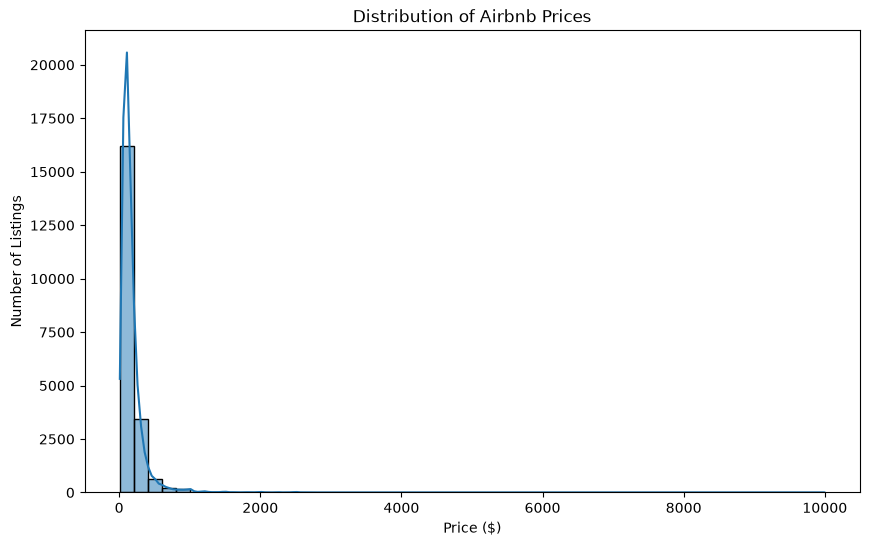

In [118]:
plt.figure(figsize=(10, 6))

sns.histplot(df['price'], bins=50, kde=True)

plt.title('Distribution of Airbnb Prices')
plt.xlabel('Price ($)')
plt.ylabel('Number of Listings')

plt.show()

## Price Distribution by Room Type

The type of accommodation is expected to have a significant effect on Airbnb
prices.

We will compare the price distributions of different room types to understand
how pricing varies between Entire homes/apartments, Private rooms, Hotel
rooms, and Shared rooms.

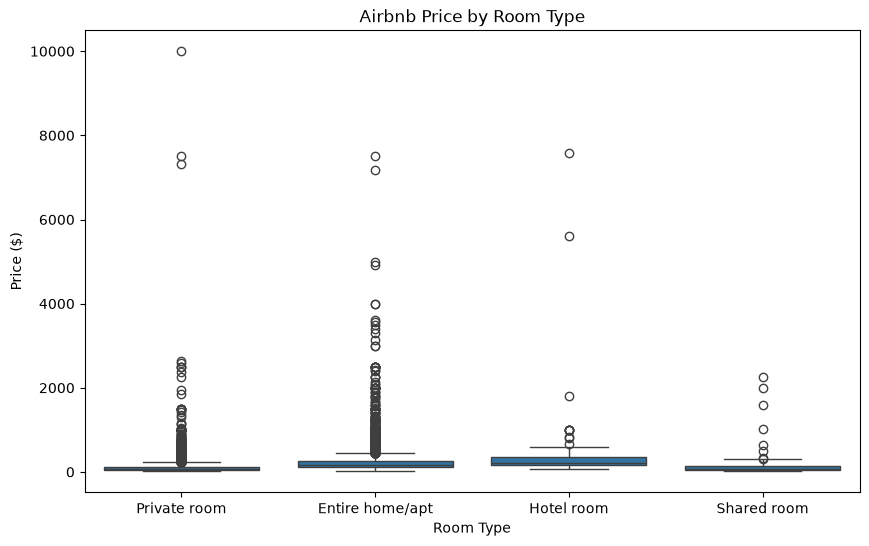

In [119]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x='room_type',
    y='price'
)

plt.title('Airbnb Price by Room Type')
plt.xlabel('Room Type')
plt.ylabel('Price ($)')

plt.show()

## Price by Neighbourhood Group

Location is one of the most important factors affecting Airbnb prices.

New York City is divided into different neighbourhood groups, and prices
may vary significantly between these areas.

We will compare the price distributions across neighbourhood groups.

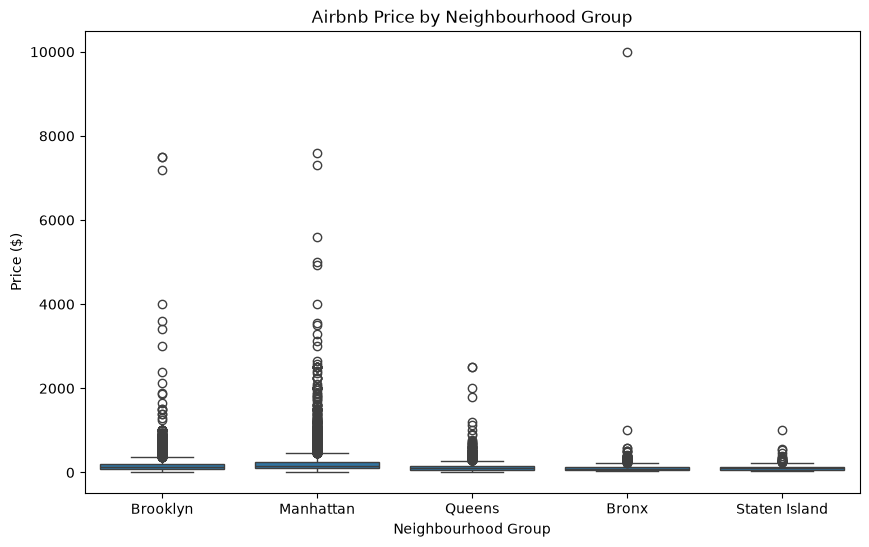

In [120]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x='neighbourhood_group',
    y='price'
)

plt.title('Airbnb Price by Neighbourhood Group')
plt.xlabel('Neighbourhood Group')
plt.ylabel('Price ($)')

plt.show()

## Relationship Between Bedrooms and Price

The number of bedrooms represents the size of an Airbnb property and is
expected to influence its price.

We will examine how Airbnb prices vary with the number of bedrooms.

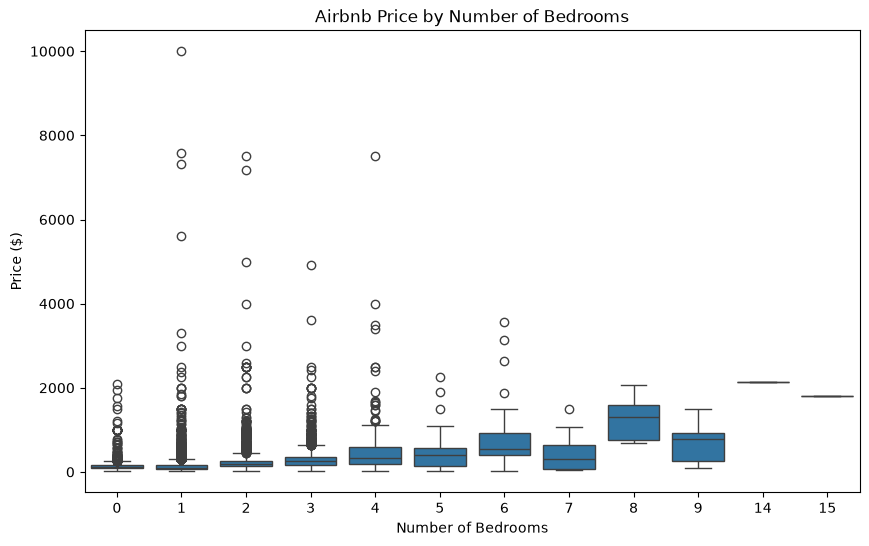

In [121]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x='bedrooms',
    y='price'
)

plt.title('Airbnb Price by Number of Bedrooms')
plt.xlabel('Number of Bedrooms')
plt.ylabel('Price ($)')

plt.show()

## Relationship Between Bathrooms and Price

The number of bathrooms can provide additional information about the size
and quality of an Airbnb listing.

We will examine whether listings with more bathrooms tend to have higher
prices.

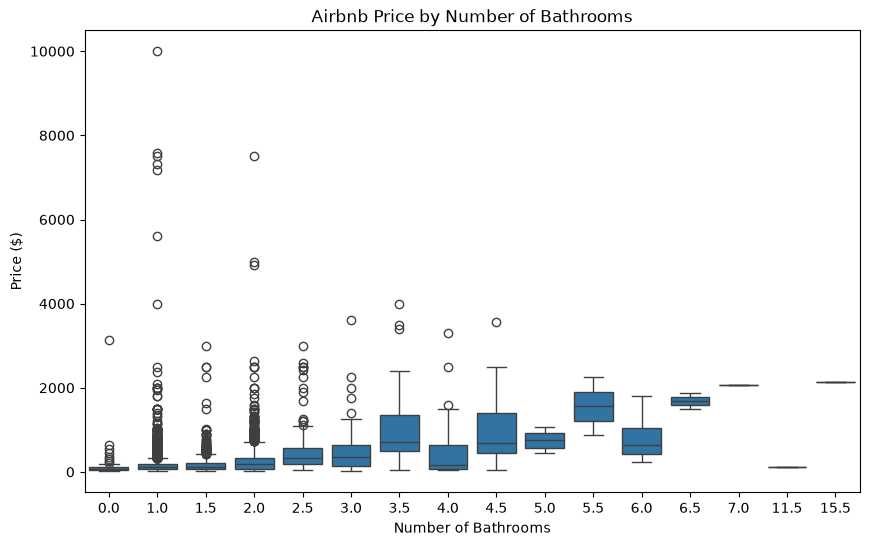

In [122]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x='baths',
    y='price'
)

plt.title('Airbnb Price by Number of Bathrooms')
plt.xlabel('Number of Bathrooms')
plt.ylabel('Price ($)')

plt.show()

## Correlation Analysis

Correlation analysis helps us understand the linear relationship between
numerical variables.

We will examine the correlations between the numerical features and the
target variable, `price`.

A positive correlation indicates that the variables tend to increase
together, while a negative correlation indicates an inverse relationship.

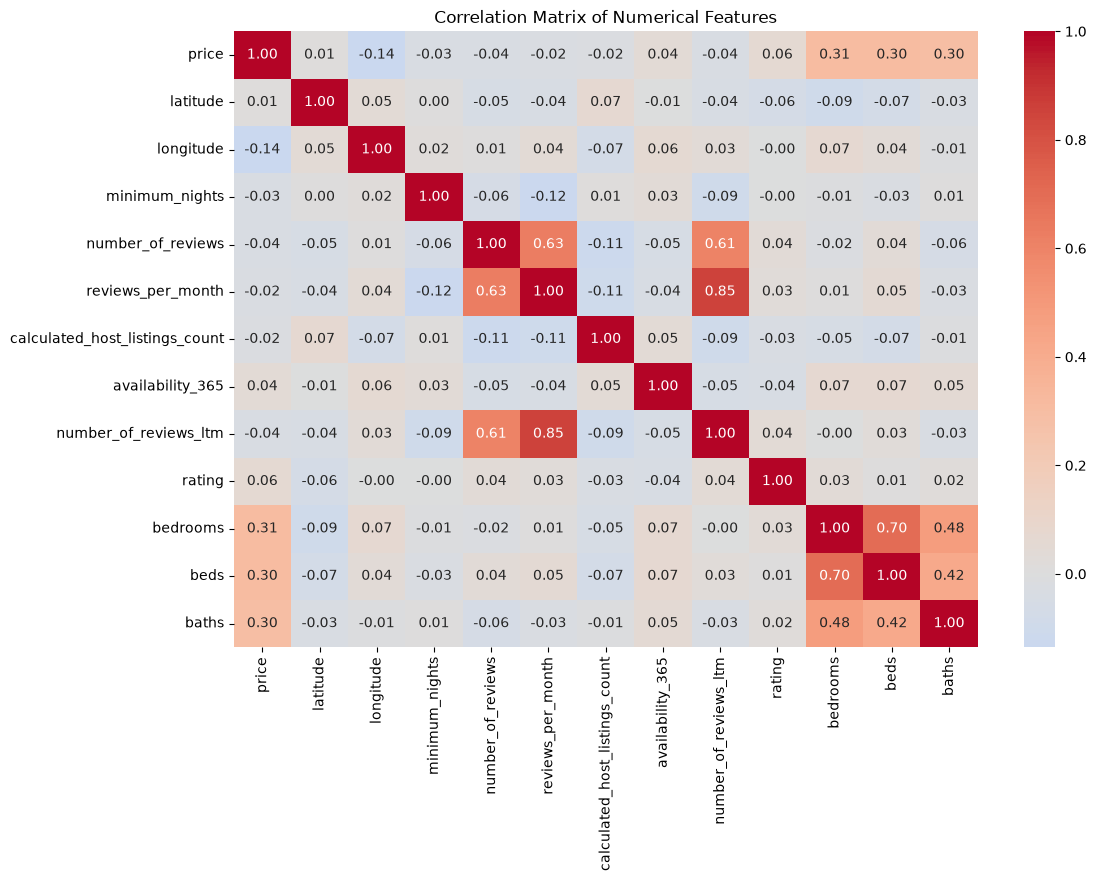

In [123]:
numeric_columns = [
    'price',
    'latitude',
    'longitude',
    'minimum_nights',
    'number_of_reviews',
    'reviews_per_month',
    'calculated_host_listings_count',
    'availability_365',
    'number_of_reviews_ltm',
    'rating',
    'bedrooms',
    'beds',
    'baths'
]

correlation = df[numeric_columns].corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Matrix of Numerical Features')

plt.show()

## Distribution of Categorical Features

Categorical variables such as room type and neighbourhood group can have a
strong influence on Airbnb prices.

We will examine the number of listings in each category before preparing
these variables for machine learning.

In [124]:
print("Room Type Distribution:")
print(df['room_type'].value_counts())

print("\nNeighbourhood Group Distribution:")
print(df['neighbourhood_group'].value_counts())

Room Type Distribution:
room_type
Entire home/apt    11547
Private room        8799
Shared room          292
Hotel room           112
Name: count, dtype: int64

Neighbourhood Group Distribution:
neighbourhood_group
Manhattan        8033
Brooklyn         7717
Queens           3760
Bronx             949
Staten Island     291
Name: count, dtype: int64


## Final Dataset Check Before Model Preparation

Before splitting the dataset into training and testing sets, we will perform
a final check of the selected features and verify that there are no missing
values remaining.

In [125]:
print("Dataset shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nSelected columns:")
print(df.columns.tolist())

Dataset shape: (20750, 16)

Missing values:
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
number_of_reviews_ltm             0
rating                            0
bedrooms                          0
beds                              0
baths                             0
dtype: int64

Selected columns:
['neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'number_of_reviews_ltm', 'rating', 'bedrooms', 'beds', 'baths']


In [126]:
numeric_features = [
    'latitude',
    'longitude',
    'minimum_nights',
    'number_of_reviews',
    'reviews_per_month',
    'calculated_host_listings_count',
    'availability_365',
    'rating',
    'bedrooms',
    'beds',
    'baths'
]

categorical_features = [
    'neighbourhood_group',
    'neighbourhood',
    'room_type'
]

## Splitting the Dataset

The dataset is divided into training and testing sets.

The training data will be used to train the machine learning models, while
the testing data will be kept separate and used to evaluate their
performance on unseen listings.

We use an 80:20 split, with 80% of the data for training and 20% for testing.

In [127]:
from sklearn.model_selection import train_test_split

X = df[numeric_features + categorical_features]
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (16600, 14)
Testing set: (4150, 14)


## Data Preprocessing

Machine learning algorithms require numerical input.

Our dataset contains both numerical and categorical features. Numerical
features can be passed directly to most tree-based models, while categorical
features such as neighbourhood and room type need to be converted into
numerical form.

We will use a preprocessing pipeline so that the same transformations are
applied consistently to both training and testing data.

In [128]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

## Building the Preprocessing Pipeline

The dataset contains both numerical and categorical features.

Numerical features will be passed through without modification, while
categorical features will be converted into numerical values using
One-Hot Encoding.

The preprocessing is placed inside a pipeline so that the same
transformations are automatically applied to both training data and
unseen data.

In [129]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ]
)

## Building the First Machine Learning Model

We will start with Linear Regression as our baseline model.

A baseline model gives us a reference point that we can use to compare
the performance of more advanced machine learning models later.

The preprocessing and model will be combined into a single pipeline so
that the required transformations are automatically performed before
prediction.

In [130]:
from sklearn.linear_model import LinearRegression

linear_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

## Training the Linear Regression Model

The model will now be trained using the training dataset.

During training, the preprocessing pipeline will convert the categorical
features into numerical values and then fit the Linear Regression model
using the transformed training data.

In [131]:
linear_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](14,)","['latitude','longitude','minimum_nights',...,'neighbourhood_group', 'neighbourhood','room_type']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,14
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed throug

## Making Predictions on the Test Data

The trained Linear Regression model will now be used to predict Airbnb
prices for the test dataset.

The test data has not been used during training, so these predictions
will help us evaluate how well the model performs on unseen listings.

In [132]:
y_pred_linear = linear_model.predict(X_test)

print("First 10 predicted prices:")
print(y_pred_linear[:10])

First 10 predicted prices:
[ 84.51579363 137.55235167 140.40542929 183.65200429  58.25261873
 365.47079874 187.74481248  77.080773   369.51128646 232.52917102]


## Evaluating the Linear Regression Model

We will evaluate the model using three common regression metrics:

- **MAE (Mean Absolute Error):** Average absolute difference between the
  predicted and actual prices.
- **RMSE (Root Mean Squared Error):** Measures prediction error while giving
  greater importance to larger errors.
- **R² Score:** Indicates how much of the variation in Airbnb prices is
  explained by the model. A higher value generally indicates better
  performance.

In [133]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_linear = mean_absolute_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))
r2_linear = r2_score(y_test, y_pred_linear)

print("Linear Regression Performance")
print("--------------------------------")
print("MAE :", round(mae_linear, 2))
print("RMSE:", round(rmse_linear, 2))
print("R²  :", round(r2_linear, 4))

Linear Regression Performance
--------------------------------
MAE : 82.41
RMSE: 208.57
R²  : 0.2435


## Random Forest Regression

Random Forest Regression is an ensemble learning algorithm that combines
multiple decision trees to make predictions.

Unlike Linear Regression, Random Forest can capture complex and non-linear
relationships between Airbnb features and price.

We will train a Random Forest model and compare its performance with the
Linear Regression baseline.

In [134]:
from sklearn.ensemble import RandomForestRegressor

random_forest_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

## Training the Random Forest Model

The Random Forest model will now be trained using the same training data
used for Linear Regression.

Using the same training and testing sets allows us to make a fair
comparison between the two models.

In [135]:
random_forest_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](14,)","['latitude','longitude','minimum_nights',...,'neighbourhood_group', 'neighbourhood','room_type']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,14
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed throug

## Making Predictions with Random Forest

The trained Random Forest model will be used to predict prices for the
unseen test data.

These predictions will then be evaluated using the same metrics used for
Linear Regression so that the two models can be compared fairly.

In [136]:
y_pred_rf = random_forest_model.predict(X_test)

print("First 10 Random Forest predictions:")
print(y_pred_rf[:10])

First 10 Random Forest predictions:
[ 76.395 151.35  111.405 184.385  69.55  879.675 199.145  76.89  353.41
 190.935]


## Evaluating the Random Forest Model

We will evaluate the Random Forest model using MAE, RMSE, and R².

These results will be compared with the Linear Regression baseline to
determine whether Random Forest provides better predictions.

In [137]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Performance")
print("-------------------------")
print("MAE :", round(mae_rf, 2))
print("RMSE:", round(rmse_rf, 2))
print("R²  :", round(r2_rf, 4))


Random Forest Performance
-------------------------
MAE : 67.26
RMSE: 202.11
R²  : 0.2896


In [138]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [mae_linear, mae_rf],
    'RMSE': [rmse_linear, rmse_rf],
    'R²': [r2_linear, r2_rf]
})

comparison

,Model,MAE,RMSE,R²
0,Linear Regression,82.40833,208.569956,0.243475
1,Random Forest,67.25751,202.114967,0.289577


## Gradient Boosting Regression

Gradient Boosting Regression is an ensemble machine learning algorithm that
builds multiple decision trees sequentially.

Each new tree attempts to correct the errors made by the previous trees.
This allows the model to capture complex and non-linear relationships
between Airbnb listing characteristics and price.

We will train a Gradient Boosting model and compare its performance with
Linear Regression and Random Forest.

In [139]:
from sklearn.ensemble import GradientBoostingRegressor

gradient_boosting_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

## Training the Gradient Boosting Model

The Gradient Boosting model will now be trained using the training dataset.

The preprocessing pipeline will automatically convert the categorical features
into numerical features before the model is trained.

After training, the model will be used to predict Airbnb prices for the
unseen testing dataset.

In [140]:
gradient_boosting_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](14,)","['latitude','longitude','minimum_nights',...,'neighbourhood_group', 'neighbourhood','room_type']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,14
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed throug

## Making Predictions with Gradient Boosting

After training the Gradient Boosting model, we will use it to predict the
prices of the listings in the testing dataset.

These predictions will then be compared with the actual prices to evaluate
the performance of the model.

In [141]:
y_pred_gb = gradient_boosting_model.predict(X_test)

print("First 10 Gradient Boosting predictions:")
print(y_pred_gb[:10])

First 10 Gradient Boosting predictions:
[100.73843643 154.61505434 129.11432018 197.1613983   80.3088777
 362.94341173 176.75027322  86.65202863 354.70226712 200.80706044]


## Evaluating the Gradient Boosting Model

The Gradient Boosting model will be evaluated using Mean Absolute Error (MAE),
Root Mean Squared Error (RMSE), and R² score.

These metrics will be compared with the Linear Regression and Random Forest
models to determine which model performs best for Airbnb price prediction.

In [142]:
mae_gb = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2_gb = r2_score(y_test, y_pred_gb)

print("Gradient Boosting Performance")
print("-----------------------------")
print("MAE :", round(mae_gb, 2))
print("RMSE:", round(rmse_gb, 2))
print("R²  :", round(r2_gb, 4))

Gradient Boosting Performance
-----------------------------
MAE : 72.02
RMSE: 204.96
R²  : 0.2694


## Comparing All Regression Models

The performance of the three regression models is compared using MAE, RMSE,
and R² score.

A lower MAE and RMSE indicate smaller prediction errors, while a higher R²
indicates that the model explains more variation in Airbnb prices.

The best-performing model will be selected for further optimization.

In [143]:
comparison = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest',
        'Gradient Boosting'
    ],
    'MAE': [
        mae_linear,
        mae_rf,
        mae_gb
    ],
    'RMSE': [
        rmse_linear,
        rmse_rf,
        rmse_gb
    ],
    'R²': [
        r2_linear,
        r2_rf,
        r2_gb
    ]
})

comparison.sort_values('R²', ascending=False)

,Model,MAE,RMSE,R²
1,Random Forest,67.257510,202.114967,0.289577
2,Gradient Boosting,72.021295,204.963825,0.269409
0,Linear Regression,82.408330,208.569956,0.243475


## XGBoost Regression

XGBoost (Extreme Gradient Boosting) is a powerful ensemble learning
algorithm based on decision trees.

It builds trees sequentially, where each new tree attempts to improve the
errors made by the previous trees.

XGBoost is widely used for structured and tabular datasets and can capture
complex relationships between Airbnb listing characteristics and price.

We will train XGBoost using the same preprocessing pipeline and compare its
performance with the previous models.


In [144]:
import xgboost as xgb

print("XGBoost version:", xgb.__version__)

XGBoost version: 3.4.1


## Building the XGBoost Regression Model

XGBoost is an advanced gradient boosting algorithm designed to achieve
strong predictive performance on structured and tabular datasets.

It builds decision trees sequentially and uses the errors from previous
trees to improve subsequent predictions.

We will use XGBoost with the same preprocessing pipeline used for the
previous models so that the comparison remains fair.

In [145]:
from xgboost import XGBRegressor

xgboost_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='reg:squarederror',
        random_state=42,
        n_jobs=-1
    ))
])


## Training the XGBoost Model

The XGBoost model will now be trained using the training dataset.

The same preprocessing pipeline is used so that the categorical variables are
encoded consistently with the previous models.

After training, the model will be evaluated on the unseen testing dataset.


In [146]:
xgboost_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](14,)","['latitude','longitude','minimum_nights',...,'neighbourhood_group', 'neighbourhood','room_type']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,14
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed throug

## Making Predictions with XGBoost

After training the XGBoost model, we will use it to predict the prices of the
listings in the testing dataset.

These predictions will be compared with the actual prices using MAE, RMSE,
and R² score.

In [147]:
y_pred_xgb = xgboost_model.predict(X_test)

print("First 10 XGBoost predictions:")
print(y_pred_xgb[:10])

First 10 XGBoost predictions:
[100.52629 147.71817 107.23599 213.62215  72.48787 853.0876  200.1956
  87.84134 367.15488 221.1275 ]


## Evaluating the XGBoost Model

The XGBoost model will be evaluated using Mean Absolute Error (MAE),
Root Mean Squared Error (RMSE), and R² score.

These metrics will be compared with the previous regression models to
determine which model currently provides the best performance.

In [148]:
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost Performance")
print("-------------------")
print("MAE :", round(mae_xgb, 2))
print("RMSE:", round(rmse_xgb, 2))
print("R²  :", round(r2_xgb, 4))


XGBoost Performance
-------------------
MAE : 68.51
RMSE: 203.46
R²  : 0.2801


## Final Comparison of Regression Models

Four regression algorithms have been evaluated for Airbnb price prediction:
Linear Regression, Random Forest, Gradient Boosting, and XGBoost.

The models are compared using MAE, RMSE, and R² score. Lower MAE and RMSE
indicate better prediction accuracy, while a higher R² indicates that the
model explains more variation in the target variable.

The best-performing model will be selected for further analysis and
optimization.

In [149]:
comparison = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest',
        'Gradient Boosting',
        'XGBoost'
    ],
    'MAE': [
        mae_linear,
        mae_rf,
        mae_gb,
        mae_xgb
    ],
    'RMSE': [
        rmse_linear,
        rmse_rf,
        rmse_gb,
        rmse_xgb
    ],
    'R²': [
        r2_linear,
        r2_rf,
        r2_gb,
        r2_xgb
    ]
})

comparison = comparison.sort_values('R²', ascending=False)

comparison

,Model,MAE,RMSE,R²
1,Random Forest,67.257510,202.114967,0.289577
3,XGBoost,68.505686,203.461628,0.280079
2,Gradient Boosting,72.021295,204.963825,0.269409
0,Linear Regression,82.408330,208.569956,0.243475


## Hyperparameter Tuning of Random Forest

Random Forest is currently the best-performing model based on the evaluation
results.

However, the model parameters used so far were selected manually. Different
values of parameters such as the number of trees, tree depth, and minimum
samples required for splitting can affect model performance.

We will use hyperparameter tuning to search for a better combination of
parameters and attempt to improve the Random Forest model.

In [150]:
from sklearn.model_selection import RandomizedSearchCV

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ))
])

param_distributions = {
    'model__n_estimators': [200, 300, 400, 500],
    'model__max_depth': [None, 10, 20, 30, 40],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': [1.0, 'sqrt', 0.7]
}

random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_distributions,
    n_iter=15,
    cv=3,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

## Running Random Forest Hyperparameter Tuning

RandomizedSearchCV will test multiple combinations of Random Forest
hyperparameters using cross-validation.

The combination that produces the best validation performance will be
selected automatically.

This process may take some time because multiple Random Forest models
will be trained.

In [151]:
random_search.fit(X_train, y_train)

Fitting 3 folds for each of 15 candidates, totalling 45 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__max_depth': [None, 10, ...], 'model__max_features': [1.0, 'sqrt', ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",15
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best

## Best Random Forest Parameters

After hyperparameter tuning, we will inspect the parameter combination
that produced the best cross-validation performance.

In [152]:
print("Best Parameters:")
print(random_search.best_params_)

print("\nBest Cross-Validation RMSE:")
print(round(-random_search.best_score_, 2))

Best Parameters:
{'model__n_estimators': 300, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': 'sqrt', 'model__max_depth': 40}

Best Cross-Validation RMSE:
203.18


## Evaluating the Tuned Random Forest

The best hyperparameter combination identified by RandomizedSearchCV
will now be evaluated on the test dataset.

The test dataset has not been used during hyperparameter selection,
so it provides an unbiased estimate of how the tuned model performs
on unseen Airbnb listings.

In [153]:
y_pred_tuned_rf = random_search.best_estimator_.predict(X_test)

mae_tuned_rf = mean_absolute_error(y_test, y_pred_tuned_rf)
rmse_tuned_rf = np.sqrt(mean_squared_error(y_test, y_pred_tuned_rf))
r2_tuned_rf = r2_score(y_test, y_pred_tuned_rf)

print("Tuned Random Forest Performance")
print("--------------------------------")
print("MAE :", round(mae_tuned_rf, 2))
print("RMSE:", round(rmse_tuned_rf, 2))
print("R²  :", round(r2_tuned_rf, 4))

Tuned Random Forest Performance
--------------------------------
MAE : 64.5
RMSE: 192.02
R²  : 0.3588


## Log-Transformed Target Variable

The Airbnb price distribution is strongly right-skewed, with a small number
of expensive listings having much higher prices than the majority of listings.

To reduce the influence of these extreme values, we will experiment with a
log-transformed target variable using `log1p()`.

The transformation is:

**log(price + 1)**

After prediction, the values can be converted back to the original price
scale using `expm1()`.

We will compare the performance of this approach with our current tuned
Random Forest model.

In [154]:
y_train_log = np.log1p(y_train)

## Random Forest with Log-Transformed Target

We will now train a Random Forest model using the log-transformed target
variable.

The input features remain unchanged. Only the target variable is
transformed during training.

After prediction, the predicted values will be converted back to the
original price scale using `expm1()`.

In [155]:
rf_log_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=300,
        max_depth=40,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features='sqrt',
        random_state=42,
        n_jobs=-1
    ))
])

rf_log_model.fit(X_train, y_train_log)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](14,)","['latitude','longitude','minimum_nights',...,'neighbourhood_group', 'neighbourhood','room_type']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,14
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed throug

## Predictions from the Log-Transformed Model

The model was trained using `log1p(price)`, so its predictions are also
on the logarithmic scale.

We will use `expm1()` to convert the predictions back to the original
Airbnb price scale before calculating the evaluation metrics.

In [159]:
y_pred_log_rf = rf_log_model.predict(X_test)

# Convert predictions back to original price scale
y_pred_log_rf = np.expm1(y_pred_log_rf)

print("First 10 predicted prices:")
print(y_pred_log_rf[:10])


First 10 predicted prices:
[ 79.68336046 153.92600312 109.95292444 181.17489122  64.31812519
 604.15508758  99.10940577  91.739872   389.3707915  169.7647913 ]


## Evaluating the Log-Transformed Random Forest

The predictions have been converted back to the original price scale.

We will now evaluate the model using Mean Absolute Error (MAE),
Root Mean Squared Error (RMSE), and R² score.

These results will be compared with the tuned Random Forest model.

In [160]:
mae_log_rf = mean_absolute_error(y_test, y_pred_log_rf)
rmse_log_rf = np.sqrt(mean_squared_error(y_test, y_pred_log_rf))
r2_log_rf = r2_score(y_test, y_pred_log_rf)

print("Log-Transformed Random Forest Performance")
print("------------------------------------------")
print("MAE :", round(mae_log_rf, 2))
print("RMSE:", round(rmse_log_rf, 2))
print("R²  :", round(r2_log_rf, 4))

Log-Transformed Random Forest Performance
------------------------------------------
MAE : 60.6
RMSE: 201.75
R²  : 0.2921


Model Comparison
| Model                   |     MAE ↓ |     RMSE ↓ |       R² ↑ |
| ----------------------- | --------: | ---------: | ---------: |
| Linear Regression       |     82.41 |     208.57 |     0.2435 |
| Random Forest           |     67.26 |     202.11 |     0.2896 |
| Gradient Boosting       |     72.02 |     204.96 |     0.2694 |
| XGBoost                 |     68.51 |     203.46 |     0.2801 |
| **Tuned Random Forest** | **64.50** | **192.02** | **0.3588** |
| Log Random Forest       |     60.60 |     201.75 |     0.2921 |

The log model has a lower MAE, but the tuned Random Forest is clearly better overall because it has substantially better RMSE and R².

So for the final system, I'd choose:

Tuned Random Forest as the final model.


## Calculating Feature Importance

We will extract the feature names and their importance values from the
best tuned Random Forest model.

The preprocessing pipeline converted categorical features into multiple
one-hot encoded features, so we will use the preprocessing pipeline to
retrieve the final feature names.

In [162]:
feature_names = random_search.best_estimator_ \
    .named_steps['preprocessor'] \
    .get_feature_names_out()

importances = random_search.best_estimator_ \
    .named_steps['model'] \
    .feature_importances_

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

feature_importance.head(15)

,Feature,Importance
1,num__longitude,0.109475
0,num__latitude,0.090039
10,num__baths,0.087492
4,num__reviews_per_month,0.085460
6,num__availability_365,0.077005
7,num__rating,0.075201
3,num__number_of_reviews,0.072838
8,num__bedrooms,0.072653
9,num__beds,0.056571
5,num__calculated_host_listings_count,0.041674


## Visualizing Feature Importance

Feature importance shows which features have the greatest influence on
the predictions made by the Random Forest model.

The most important features will be visualized using a horizontal bar
chart so that they can be easily compared.

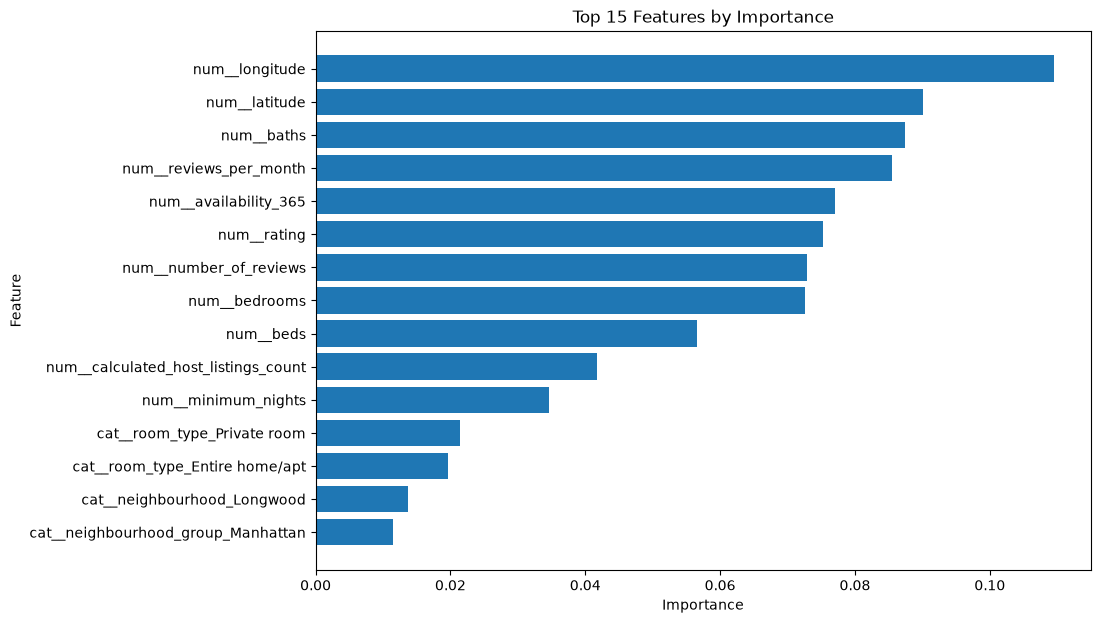

In [ ]:
feature_importance_top = feature_importance.head(15).sort_values(
    'Importance', ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    feature_importance_top['Feature'],
    feature_importance_top['Importance']
)

plt.title('Top 15 Features by Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

## Actual vs Predicted Prices

To visually evaluate the performance of the final Random Forest model,
we will compare the actual Airbnb prices with the prices predicted by
the tuned Random Forest model.

If the predictions are accurate, the points should be close to the
diagonal line where:

**Actual Price = Predicted Price**

Large deviations from the diagonal line indicate prediction errors.

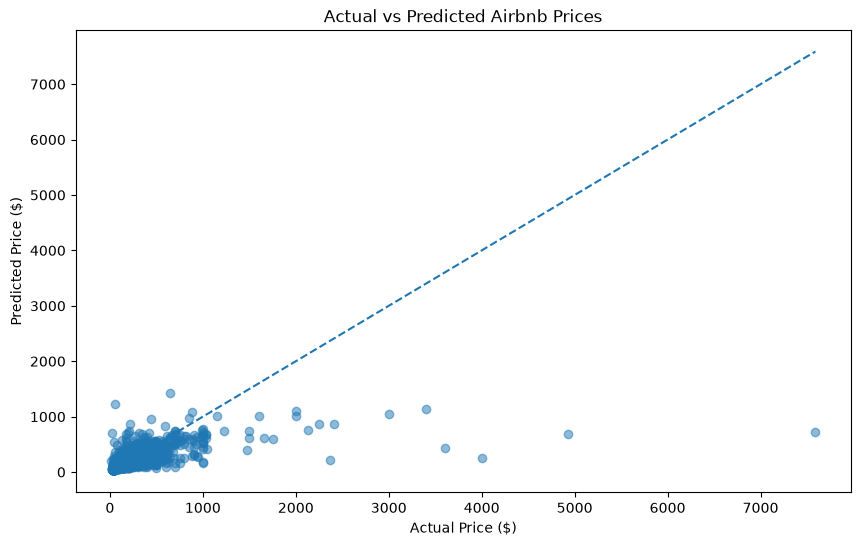

In [164]:
plt.figure(figsize=(10, 6))

plt.scatter(
    y_test,
    y_pred_tuned_rf,
    alpha=0.5
)

# Perfect prediction line
min_price = min(y_test.min(), y_pred_tuned_rf.min())
max_price = max(y_test.max(), y_pred_tuned_rf.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle='--'
)

plt.title('Actual vs Predicted Airbnb Prices')
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')

plt.show()

## Residual Analysis

Residuals represent the difference between the actual price and the
predicted price.

The residual is calculated as:

**Residual = Actual Price - Predicted Price**

A residual close to zero means that the prediction is close to the
actual price.

We will analyze the distribution of residuals to identify patterns and
large prediction errors.

In [165]:
residuals = y_test - y_pred_tuned_rf

print("Residual Statistics")
print("-------------------")
print("Mean Residual:", round(residuals.mean(), 2))
print("Median Residual:", round(residuals.median(), 2))
print("Minimum Residual:", round(residuals.min(), 2))
print("Maximum Residual:", round(residuals.max(), 2))

Residual Statistics
-------------------
Mean Residual: 0.47
Median Residual: -14.93
Minimum Residual: -1174.62
Maximum Residual: 6872.81


## Residual Distribution

A residual distribution plot helps us understand how the prediction errors
are distributed around zero.

Ideally, residuals should be centered around zero without a strong systematic
pattern.

A wide distribution indicates larger prediction errors, while values far
from zero represent listings where the model performed poorly.

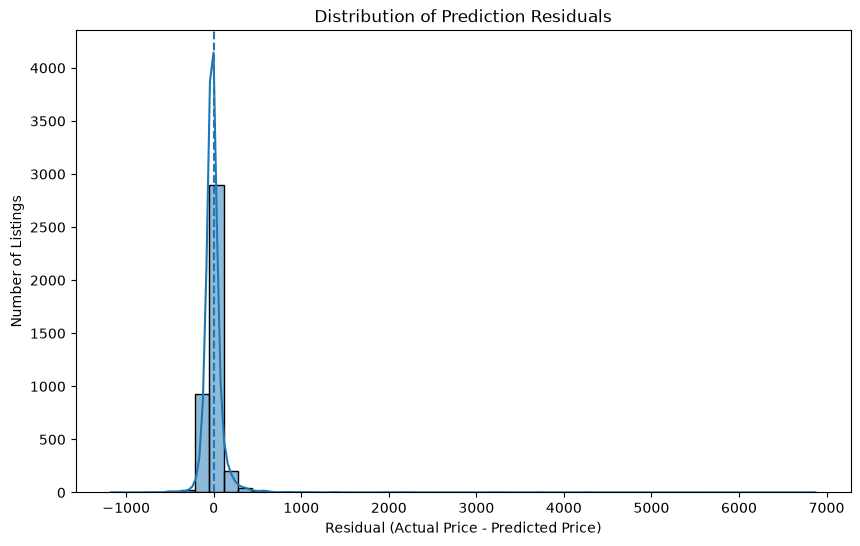

In [166]:
plt.figure(figsize=(10, 6))

sns.histplot(residuals, bins=50, kde=True)

plt.axvline(0, linestyle='--')

plt.title('Distribution of Prediction Residuals')
plt.xlabel('Residual (Actual Price - Predicted Price)')
plt.ylabel('Number of Listings')

plt.show()

## Prediction Accuracy Within a Percentage Error

Since this is a regression problem, traditional classification accuracy
is not appropriate.

Instead, we can calculate the percentage of predictions that fall within
a specified percentage of the actual Airbnb price.

For example, a prediction is considered accurate if it is within 20% of
the actual price.

In [167]:
percentage_error = (
    np.abs((y_test - y_pred_tuned_rf) / y_test)
) * 100

accuracy_20 = np.mean(percentage_error <= 20) * 100
accuracy_10 = np.mean(percentage_error <= 10) * 100
accuracy_30 = np.mean(percentage_error <= 30) * 100

print("Predictions within 10% :", round(accuracy_10, 2), "%")
print("Predictions within 20% :", round(accuracy_20, 2), "%")
print("Predictions within 30% :", round(accuracy_30, 2), "%")

Predictions within 10% : 20.77 %
Predictions within 20% : 38.43 %
Predictions within 30% : 53.45 %


## Experiment: Removing Extreme Price Listings

The original dataset contains a small number of extremely expensive listings
that produce very large prediction errors.

In this experiment, we will remove listings with prices above $2,000 and
train the model again.

This is an experimental comparison. The original model and its results will
be retained so that we can determine whether removing extreme prices actually
improves model performance.

In [213]:
# Create a separate dataset without extreme high-price listings
df_filtered = df[df['price'] <= 500].copy()

print("Original dataset:", df.shape)
print("Filtered dataset:", df_filtered.shape)

print("\nMaximum price after filtering:", df_filtered['price'].max())

Original dataset: (20750, 16)
Filtered dataset: (20028, 16)

Maximum price after filtering: 500.0


## Train-Test Split for the Filtered Dataset

The filtered dataset contains only listings priced at or below $2,000.

We will now split this dataset into training and testing sets using the same
80:20 ratio and random state as the original experiment.

Using the same split settings makes the experiment consistent and easier to
compare with the original model.

In [206]:
X_filtered = df_filtered[numeric_features + categorical_features]
y_filtered = df_filtered['price']

X_train_filtered, X_test_filtered, y_train_filtered, y_test_filtered = train_test_split(
    X_filtered,
    y_filtered,
    test_size=0.20,
    random_state=42
)

print("Training set:", X_train_filtered.shape)
print("Testing set:", X_test_filtered.shape)

Training set: (16565, 14)
Testing set: (4142, 14)


## Training Random Forest on the Filtered Dataset

We will now train the tuned Random Forest configuration on the filtered
dataset.

The model parameters are kept the same as the previous tuned model so that
any change in performance can be attributed primarily to removing the
extreme-price listings.

In [207]:
filtered_rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=300,
        max_depth=40,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features='sqrt',
        random_state=42,
        n_jobs=-1
    ))
])

filtered_rf_model.fit(X_train_filtered, y_train_filtered)

print("Filtered Random Forest model trained successfully.")


Filtered Random Forest model trained successfully.


## Evaluating the Filtered Random Forest Model

The filtered Random Forest model will now be used to predict prices for
the unseen testing data.

We will evaluate the model using three regression metrics:

- **MAE:** Average absolute prediction error
- **RMSE:** Penalizes large prediction errors more strongly
- **R²:** Measures how much of the variation in price is explained by the model

These results will be compared with our previous tuned Random Forest:
**R² = 0.359, RMSE = $192.02, and MAE = $64.50.**

In [208]:
y_pred_filtered_rf = filtered_rf_model.predict(X_test_filtered)

mae_filtered_rf = mean_absolute_error(
    y_test_filtered,
    y_pred_filtered_rf
)

rmse_filtered_rf = np.sqrt(
    mean_squared_error(
        y_test_filtered,
        y_pred_filtered_rf
    )
)

r2_filtered_rf = r2_score(
    y_test_filtered,
    y_pred_filtered_rf
)

print("Filtered Random Forest Performance")
print("-----------------------------------")
print("MAE :", round(mae_filtered_rf, 2))
print("RMSE:", round(rmse_filtered_rf, 2))
print("R²  :", round(r2_filtered_rf, 4))

Filtered Random Forest Performance
-----------------------------------
MAE : 57.06
RMSE: 111.8
R²  : 0.5342


## XGBoost on the Filtered Dataset

The filtered Random Forest achieved an R² score of 0.5342.

Since additional location features did not improve the Random Forest, we will
now test XGBoost on the filtered dataset.

XGBoost is a powerful gradient boosting algorithm that can capture complex
non-linear relationships in structured data.

We will use the same filtered training and testing data so that the results
can be compared fairly with the filtered Random Forest.

In [209]:
filtered_xgb_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='reg:squarederror',
        random_state=42,
        n_jobs=-1
    ))
])

filtered_xgb_model.fit(X_train_filtered, y_train_filtered)

print("Filtered XGBoost model trained successfully.")

Filtered XGBoost model trained successfully.


## Evaluating Filtered XGBoost

The XGBoost model has been trained using the filtered dataset containing
listings priced at $2,000 or less.

We will now evaluate its performance using MAE, RMSE, and R² and compare
the results with the filtered Random Forest model.

The filtered Random Forest achieved an R² of 0.5342, an RMSE of $111.80,
and an MAE of $57.06.

In [211]:
y_pred_filtered_xgb = filtered_xgb_model.predict(X_test_filtered)

mae_filtered_xgb = mean_absolute_error(
    y_test_filtered,
    y_pred_filtered_xgb
)

rmse_filtered_xgb = np.sqrt(
    mean_squared_error(
        y_test_filtered,
        y_pred_filtered_xgb
    )
)

r2_filtered_xgb = r2_score(
    y_test_filtered,
    y_pred_filtered_xgb
)

print("Filtered XGBoost Performance")
print("----------------------------")
print("MAE :", round(mae_filtered_xgb, 2))
print("RMSE:", round(rmse_filtered_xgb, 2))
print("R²  :", round(r2_filtered_xgb, 4))

Filtered XGBoost Performance
----------------------------
MAE : 57.45
RMSE: 110.13
R²  : 0.548


## Hyperparameter Tuning of Filtered XGBoost

The filtered XGBoost model currently achieves an R² score of 0.5480.

XGBoost has several hyperparameters that control the complexity and learning
behavior of the model.

We will use RandomizedSearchCV with cross-validation to search for a better
combination of parameters.

The goal is to improve the model's performance without simply increasing
the number of trees or model complexity manually.

In [214]:
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(
        objective='reg:squarederror',
        random_state=42,
        n_jobs=-1
    ))
])

xgb_param_distributions = {
    'model__n_estimators': [300, 500, 700, 1000],
    'model__learning_rate': [0.02, 0.03, 0.05, 0.08],
    'model__max_depth': [3, 4, 5, 6, 7, 8],
    'model__min_child_weight': [1, 3, 5, 7],
    'model__subsample': [0.7, 0.8, 0.9, 1.0],
    'model__colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'model__gamma': [0, 0.1, 0.3, 0.5],
    'model__reg_alpha': [0, 0.01, 0.1],
    'model__reg_lambda': [1, 1.5, 2, 5]
}

xgb_random_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=xgb_param_distributions,
    n_iter=20,
    cv=3,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

## Running XGBoost Hyperparameter Search

The hyperparameter search has been configured with 20 different parameter
combinations and 3-fold cross-validation.

The search will train and evaluate multiple XGBoost configurations and
select the combination with the lowest cross-validation RMSE.

This may take some time because several models will be trained.

In [215]:
xgb_random_search.fit(
    X_train_filtered,
    y_train_filtered
)

print("XGBoost hyperparameter search completed successfully.")

Fitting 3 folds for each of 20 candidates, totalling 60 fits
XGBoost hyperparameter search completed successfully.


## Best XGBoost Parameters

The hyperparameter search evaluated multiple XGBoost configurations using
3-fold cross-validation.

We will now display the best combination of parameters selected by the
search and its cross-validation RMSE.

In [216]:
print("Best XGBoost Parameters:")
print(xgb_random_search.best_params_)

print("\nBest Cross-Validation RMSE:")
print(round(-xgb_random_search.best_score_, 2))

Best XGBoost Parameters:
{'model__subsample': 0.8, 'model__reg_lambda': 2, 'model__reg_alpha': 0, 'model__n_estimators': 500, 'model__min_child_weight': 7, 'model__max_depth': 7, 'model__learning_rate': 0.03, 'model__gamma': 0.5, 'model__colsample_bytree': 0.8}

Best Cross-Validation RMSE:
111.46


## Evaluating Tuned XGBoost

The hyperparameter search identified the best XGBoost configuration based on
3-fold cross-validation.

We will now evaluate this tuned model on the unseen test dataset using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

These results will be compared with the previous filtered XGBoost model,
which achieved an R² of 0.5480.

In [217]:
y_pred_tuned_xgb = xgb_random_search.best_estimator_.predict(
    X_test_filtered
)

mae_tuned_xgb = mean_absolute_error(
    y_test_filtered,
    y_pred_tuned_xgb
)

rmse_tuned_xgb = np.sqrt(
    mean_squared_error(
        y_test_filtered,
        y_pred_tuned_xgb
    )
)

r2_tuned_xgb = r2_score(
    y_test_filtered,
    y_pred_tuned_xgb
)

print("Tuned Filtered XGBoost Performance")
print("-----------------------------------")
print("MAE :", round(mae_tuned_xgb, 2))
print("RMSE:", round(rmse_tuned_xgb, 2))
print("R²  :", round(r2_tuned_xgb, 4))

Tuned Filtered XGBoost Performance
-----------------------------------
MAE : 57.12
RMSE: 109.12
R²  : 0.5563


## Advanced Location Feature Engineering

Location is one of the most important factors affecting Airbnb prices.

Instead of relying only on raw latitude and longitude, we will create
additional geographic features that represent the listing's approximate
distance from important areas of New York City.

These features can help the model understand how the location of a listing
relates to its price.

We will calculate:

- Distance from Midtown Manhattan
- Distance from Lower Manhattan
- Distance from Central Park

In [218]:
# Create a new copy of the filtered dataset
df_location = df_filtered.copy()

# Reference coordinates for important NYC locations
midtown_lat, midtown_lon = 40.7549, -73.9840
lower_manhattan_lat, lower_manhattan_lon = 40.7128, -74.0060
central_park_lat, central_park_lon = 40.7812, -73.9665

# Distance from Midtown Manhattan
df_location['distance_midtown'] = np.sqrt(
    (df_location['latitude'] - midtown_lat) ** 2 +
    (df_location['longitude'] - midtown_lon) ** 2
)

# Distance from Lower Manhattan
df_location['distance_lower_manhattan'] = np.sqrt(
    (df_location['latitude'] - lower_manhattan_lat) ** 2 +
    (df_location['longitude'] - lower_manhattan_lon) ** 2
)

# Distance from Central Park
df_location['distance_central_park'] = np.sqrt(
    (df_location['latitude'] - central_park_lat) ** 2 +
    (df_location['longitude'] - central_park_lon) ** 2
)

print("Location features created successfully.")

df_location[
    [
        'distance_midtown',
        'distance_lower_manhattan',
        'distance_central_park'
    ]
].head()

Location features created successfully.


,distance_midtown,distance_lower_manhattan,distance_central_park
0,0.073783,0.050590,0.097508
1,0.012407,0.056709,0.026066
2,0.011383,0.039637,0.041428
3,0.090745,0.138246,0.059459
4,0.006592,0.047108,0.032422


## Preparing the Dataset with Advanced Location Features

We will add the three new geographic features to our existing numerical
features.

The model will now have information about:

- Latitude and longitude
- Distance from Midtown Manhattan
- Distance from Lower Manhattan
- Distance from Central Park
- Property characteristics
- Reviews and availability
- Neighbourhood and room type

We will keep the same filtered dataset and the same train-test split settings
so that the experiment remains comparable with our previous models.

In [219]:
# Define the new numerical feature set
location_numeric_features = numeric_features + [
    'distance_midtown',
    'distance_lower_manhattan',
    'distance_central_park'
]

# Prepare features and target
X_location = df_location[
    location_numeric_features + categorical_features
]

y_location = df_location['price']

# Train-test split
X_train_location, X_test_location, y_train_location, y_test_location = train_test_split(
    X_location,
    y_location,
    test_size=0.20,
    random_state=42
)

print("Training set:", X_train_location.shape)
print("Testing set:", X_test_location.shape)
print("Number of features:", X_location.shape[1])


Training set: (16022, 17)
Testing set: (4006, 17)
Number of features: 17


## Training XGBoost with Advanced Location Features

We will train XGBoost using the best hyperparameters identified during
the previous hyperparameter search.

The only change is the addition of the three new location-based features.

This allows us to determine whether the advanced geographic features
improve the model's predictive performance.

In [220]:
location_xgb_model = Pipeline(steps=[
    ('preprocessor', ColumnTransformer(
        transformers=[
            (
                'num',
                'passthrough',
                location_numeric_features
            ),
            (
                'cat',
                OneHotEncoder(
                    handle_unknown='ignore',
                    sparse_output=False
                ),
                categorical_features
            )
        ]
    )),
    ('model', XGBRegressor(
        subsample=0.8,
        reg_lambda=2,
        reg_alpha=0,
        n_estimators=500,
        min_child_weight=7,
        max_depth=7,
        learning_rate=0.03,
        gamma=0.5,
        colsample_bytree=0.8,
        objective='reg:squarederror',
        random_state=42,
        n_jobs=-1
    ))
])

location_xgb_model.fit(
    X_train_location,
    y_train_location
)

print("XGBoost with advanced location features trained successfully.")

XGBoost with advanced location features trained successfully.


## Evaluating XGBoost with Advanced Location Features

We will evaluate the XGBoost model using the same three regression metrics:

- MAE: Average absolute prediction error
- RMSE: Penalizes larger prediction errors more strongly
- R²: Measures how much of the variation in price is explained by the model

The previous best model achieved an R² of 0.5563.

We will check whether the new location features improve this result.

In [221]:
y_pred_location_xgb = location_xgb_model.predict(
    X_test_location
)

mae_location_xgb = mean_absolute_error(
    y_test_location,
    y_pred_location_xgb
)

rmse_location_xgb = np.sqrt(
    mean_squared_error(
        y_test_location,
        y_pred_location_xgb
    )
)

r2_location_xgb = r2_score(
    y_test_location,
    y_pred_location_xgb
)

print("XGBoost with Advanced Location Features")
print("-----------------------------------------")
print("MAE :", round(mae_location_xgb, 2))
print("RMSE:", round(rmse_location_xgb, 2))
print("R²  :", round(r2_location_xgb, 4))

XGBoost with Advanced Location Features
-----------------------------------------
MAE : 41.46
RMSE: 59.97
R²  : 0.5654


## Saving the Final Model

The XGBoost model with advanced location-based features is selected as the
final model for deployment.

The complete pipeline, including preprocessing and the trained XGBoost
model, will be saved using Joblib. This allows the same trained model to
be loaded later by the Streamlit application without retraining it.

In [224]:
import joblib

# Save the complete trained pipeline
model_path = '../models/airbnb_price_model.pkl'
joblib.dump(location_xgb_model, model_path)

print("Model saved successfully!")
print("Saved to:", model_path)

Model saved successfully!
Saved to: ../models/airbnb_price_model.pkl


## Verifying the Saved Model

The saved model will be loaded from the `models` folder to confirm that
the complete machine learning pipeline was saved correctly and can be
used for prediction without retraining.

In [225]:
import joblib

# Load the saved model
loaded_model = joblib.load('../models/airbnb_price_model.pkl')

print("Model loaded successfully!")
print("Model type:", type(loaded_model))

Model loaded successfully!
Model type: <class 'sklearn.pipeline.Pipeline'>


## Testing the Saved Model

A sample Airbnb listing will be passed to the loaded model to verify that
the saved pipeline can generate a price prediction using the same features
used during training.

In [226]:
import pandas as pd
import numpy as np

# Sample listing
sample_listing = pd.DataFrame([{
    'latitude': 40.7580,
    'longitude': -73.9855,
    'minimum_nights': 2,
    'number_of_reviews': 50,
    'reviews_per_month': 2.5,
    'calculated_host_listings_count': 3,
    'availability_365': 200,
    'rating': 4.8,
    'bedrooms': 1,
    'beds': 1,
    'baths': 1.0,
    'neighbourhood_group': 'Manhattan',
    'neighbourhood': 'Hell\'s Kitchen',
    'room_type': 'Entire home/apt',
    
    # Advanced location features
    'distance_midtown': np.sqrt(
        (40.7580 - 40.7549) ** 2 +
        (-73.9855 - (-73.9840)) ** 2
    ),
    'distance_lower_manhattan': np.sqrt(
        (40.7580 - 40.7128) ** 2 +
        (-73.9855 - (-74.0060)) ** 2
    ),
    'distance_central_park': np.sqrt(
        (40.7580 - 40.7812) ** 2 +
        (-73.9855 - (-73.9665)) ** 2
    )
}])

# Make prediction
predicted_price = loaded_model.predict(sample_listing)[0]

print(f"Predicted Airbnb Price: ${predicted_price:.2f}")

Predicted Airbnb Price: $232.91
